# Imports

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, precision_recall_curve, auc
)

import tensorflow as tf
from tensorflow.keras import layers, models

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8,5)

tf.random.set_seed(42)
np.random.seed(42)


# Load preprocessed data (from Notebook 02)

In [2]:
X_train_normal = pd.read_csv("X_train_normal.csv")
X_test = pd.read_csv("X_test.csv")
y_test = pd.read_csv("y_test.csv").squeeze()

X_train_normal.shape, X_test.shape, y_test.shape


((199020, 30), (85443, 30), (85443,))

Convert to numpy float32 (important for Keras speed):

In [3]:
X_train_np = X_train_normal.values.astype("float32")
X_test_np = X_test.values.astype("float32")


# Build a simple Autoencoder

In [4]:
input_dim = X_train_np.shape[1]

autoencoder = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(16, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(input_dim, activation="linear")
])

autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 16)                496       
                                                                 
 dense_1 (Dense)             (None, 8)                 136       
                                                                 
 dense_2 (Dense)             (None, 16)                144       
                                                                 
 dense_3 (Dense)             (None, 30)                510       
                                                                 
Total params: 1286 (5.02 KB)
Trainable params: 1286 (5.02 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


2026-02-04 19:11:27.727577: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Max
2026-02-04 19:11:27.727624: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-02-04 19:11:27.727635: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 10.67 GB
2026-02-04 19:11:27.727995: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-02-04 19:11:27.728234: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


# Train on normal-only data

Using a validation split so i can monitor overfitting.

In [5]:
history = autoencoder.fit(
    X_train_np, X_train_np,
    epochs=30,
    batch_size=512,
    validation_split=0.1,
    shuffle=True,
    verbose=1
)


Epoch 1/30


2026-02-04 19:11:28.230244: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


350/350 [==============================] - 2s 6ms/step - loss: 0.8041 - val_loss: 0.5879
Epoch 2/30
350/350 [==============================] - 2s 5ms/step - loss: 0.5638 - val_loss: 0.5588
Epoch 3/30
350/350 [==============================] - 2s 5ms/step - loss: 0.5540 - val_loss: 0.5390
Epoch 4/30
350/350 [==============================] - 2s 6ms/step - loss: 0.5871 - val_loss: 0.6611
Epoch 5/30
350/350 [==============================] - 2s 5ms/step - loss: 0.6577 - val_loss: 0.6891
Epoch 6/30
350/350 [==============================] - 2s 5ms/step - loss: 0.9535 - val_loss: 2.5631
Epoch 7/30
350/350 [==============================] - 2s 6ms/step - loss: 0.8811 - val_loss: 0.8388
Epoch 8/30
350/350 [==============================] - 2s 5ms/step - loss: 0.8569 - val_loss: 0.8098
Epoch 9/30
350/350 [==============================] - 2s 5ms/step - loss: 0.7533 - val_loss: 0.7028
Epoch 10/30
350/350 [==============================] - 2s 5ms/step - loss: 0.7382 - val_loss: 0.6880
Epoch 11/3

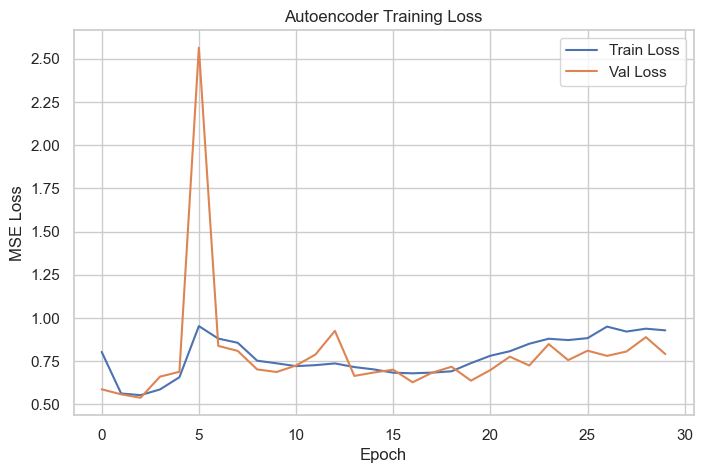

In [6]:
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Training Loss")
plt.legend()
plt.show()


# Reconstruction Error = Anomaly Score

Reconstruction error per row:
Higher recon_error = more anomalous.

In [7]:
X_test_pred = autoencoder.predict(X_test_np, verbose=0)
recon_error = np.mean(np.square(X_test_np - X_test_pred), axis=1)  # MSE per sample


# Threshold

In [8]:
X_train_pred = autoencoder.predict(X_train_np, verbose=0)
train_recon_error = np.mean(np.square(X_train_np - X_train_pred), axis=1)


In [9]:
threshold = np.quantile(train_recon_error, 0.99)
threshold


6.076092023849486

In [10]:
y_pred = (recon_error >= threshold).astype(int)


# Evaluate

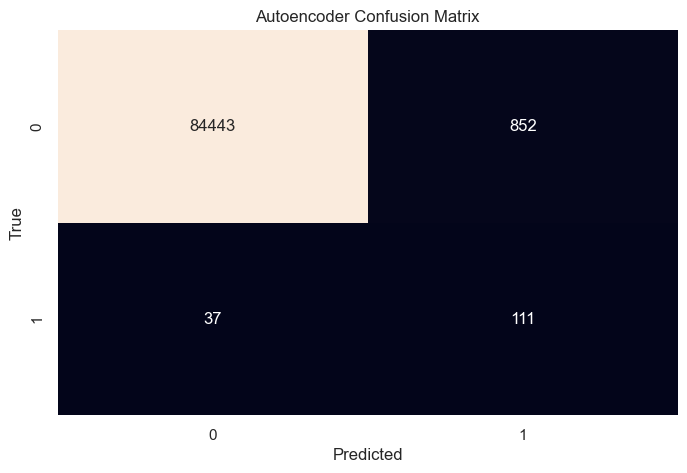

              precision    recall  f1-score   support

           0     0.9996    0.9900    0.9948     85295
           1     0.1153    0.7500    0.1998       148

    accuracy                         0.9896     85443
   macro avg     0.5574    0.8700    0.5973     85443
weighted avg     0.9980    0.9896    0.9934     85443



In [11]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cbar=False)
plt.title("Autoencoder Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print(classification_report(y_test, y_pred, digits=4))


# ROC-AUC and PR-AUC

In [12]:
roc = roc_auc_score(y_test, recon_error)
roc


0.947373741054496

In [13]:
precision, recall, thresholds = precision_recall_curve(y_test, recon_error)
pr_auc = auc(recall, precision)
pr_auc


0.29135600711593995

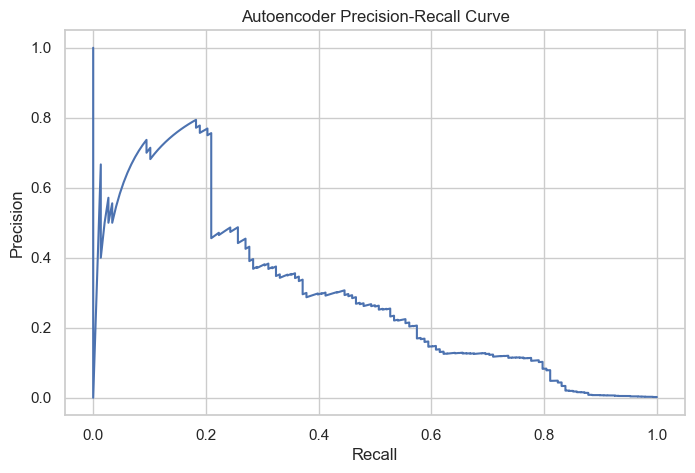

In [14]:
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Autoencoder Precision-Recall Curve")
plt.show()


# Threshold Tuning Table

In [19]:
thresholds_to_try = np.quantile(train_recon_error, [0.95, 0.97, 0.98, 0.99, 0.995])

results = []
for t in thresholds_to_try:
    y_pred_t = (recon_error >= t).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm_t.ravel()
    precision_t = tp / (tp + fp) if (tp + fp) else 0
    recall_t = tp / (tp + fn) if (tp + fn) else 0
    results.append((t, precision_t, recall_t, fp, tp))
    
# Choose a single threshold for deployment:
# 99th percentile of reconstruction error on NORMAL training data
ae_threshold = np.quantile(train_recon_error, 0.99)

ae_threshold


results_df = pd.DataFrame(results, columns=["Threshold", "Precision", "Recall", "FalsePositives", "TruePositives"])
results_df


,Threshold,Precision,Recall,FalsePositives,TruePositives
0,1.669576,0.028519,0.837838,4224,124
1,2.386426,0.045573,0.824324,2555,122
2,3.327502,0.065753,0.810811,1705,120
3,6.076092,0.115265,0.750000,852,111
4,10.008252,0.171717,0.574324,410,85


Autoencoder Summary

Trained only on normal transactions to learn “normal behaviour”

Reconstruction error used as anomaly score

Threshold selected from normal training error distribution

Evaluated with PR-AUC/ROC-AUC and threshold tuning

In [20]:
pd.DataFrame({
    "row_id": np.arange(len(y_test)),
    "y_true": y_test.values,
    "ae_recon_error": recon_error
}).to_csv("ae_scores.csv", index=False)


In [21]:
autoencoder.save("autoencoder_model")


INFO:tensorflow:Assets written to: autoencoder_model/assets


INFO:tensorflow:Assets written to: autoencoder_model/assets


In [22]:
import json

# Load existing thresholds.json (from Isolation Forest notebook)
with open("thresholds.json", "r") as f:
    thresholds = json.load(f)

# Add AE threshold
thresholds["ae_threshold"] = float(ae_threshold)

# Save back
with open("thresholds.json", "w") as f:
    json.dump(thresholds, f)

print("Updated thresholds.json:", thresholds)


Updated thresholds.json: {'iso_threshold': 0.0050549662370200565, 'ae_threshold': 6.076092023849486}
